In [463]:
# loading packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

In [464]:
# machine learning
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import PolynomialFeatures , MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, BayesianRidge 
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  , mean_absolute_percentage_error
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.cluster import KMeans


import xgboost as xgb

In [465]:
df_original = pd.read_csv("C:\\Github\\Coral_Bleaching_Predictor\\Data\\dataset.csv" , na_values=['nd']) # old data
df_original

,ID,Latitude_Degrees,Longitude_Degrees,Ocean,Realm,Ecoregion,Country_Name,State_Island_Province,City_Town,City_Town_2,...,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean
0,97,-20.899833,149.407722,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
1,98,-20.893056,149.421000,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Keswick Island,NaN,...,2.40,-3.26,3.0,1.95,7.0,1.0,3.52,1.36,8.43,0.52
2,116,-20.745806,149.472056,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,2.34,-3.06,1.0,1.47,5.0,1.0,1.51,1.23,7.32,0.49
3,117,-20.737694,149.464944,Pacific,Central Indo-Pacific,Southern Great Barrier Reef,Australia,Queensland,Wigton Island,Wigton Island Reef,...,2.64,-3.01,2.0,1.31,5.0,1.0,2.36,0.97,6.86,0.36
4,142,-20.259361,148.814583,Pacific,Central Indo-Pacific,Central and northern Great Barrier Reef,Australia,Queensland,Mount Rooper,Daydream Island,...,2.81,-3.23,4.0,1.72,7.0,1.0,0.00,1.47,9.84,0.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9660,13073,13.935889,48.386417,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Shabwah Governorate,Bi'r Ali,Eemad,...,10.59,-1.86,1.0,2.30,11.0,2.0,2.63,2.57,20.95,1.08
9661,13074,13.935889,48.386417,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Shabwah Governorate,Bi'r Ali,Eemad,...,10.59,-1.86,1.0,2.30,11.0,2.0,2.63,2.57,20.95,1.08
9662,13075,14.817722,50.015250,Red Sea,Western Indo-Pacific,Gulf of Aden,Yemen,Hadhramaut Governorate,Al-Qurn,Eemad,...,10.51,-2.13,0.0,1.97,10.0,2.0,0.00,2.74,23.70,1.09
9663,13076,15.701611,42.391806,Red Sea,Western Indo-Pacific,South Red Sea,Yemen,Al Hudaydah Governorate,Jazirat Antufash,Seaem,...,2.52,-2.69,0.0,1.63,6.0,1.0,0.00,1.33,8.30,0.54


In [466]:
print(f"total number of rows and columns in the dataset: {len(df_original.columns)} columns, {len(df_original)} rows")

total number of rows and columns in the dataset: 48 columns, 9665 rows


In [467]:
## Grouping years into decodes
def Cleaning_date_to_year(df):
    #Changing date to year
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year # New columns with only year 
    
    year_counts = df.groupby(['Year']).size()
    print(year_counts)
    

    return df

df_Makedatetime = Cleaning_date_to_year(df_original)

Year
1998      5
2000      2
2001      3
2002     63
2003    599
2004    731
2005    700
2006    850
2007    643
2008    692
2009    721
2010    538
2011    533
2012    563
2013    626
2014    600
2015    615
2016    619
2017    562
dtype: int64


In [468]:
#Check NAN Data and by what percentage
def nan_check(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent_1 = data.isnull().sum()/data.isnull().count()*100
    percent_2 = (np.round(percent_1, 1)).sort_values(ascending=False)
    missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
    return missing_data

Missing  = nan_check(df_Makedatetime)

In [469]:
def Columns_percent_missing(df,df_dtype, col):
    
    count_less = 0
    count_more = 0
    Index_more = []
    Index_less = []
    for_drop = []
    type_object = []
    type_number = []
    for idx, value in df[col].items():
        if value >= 0.4:
            count_more += 1
            Index_more.append(idx)
            for_drop.append(idx)
        elif value < 0.4:
            count_less += 1
            Index_less.append(idx)
            
    for i in df_dtype.columns:
        if df_dtype[i].dtype == 'object':
            type_object.append(i)
        else:
            type_number.append(i)

    print("\n")
    print(f"more than 0.4% : {count_more}")
    print(f"less than 0.4% : {count_less}")
    print(f"Index_more : {len(Index_more)} attribuue : {Index_more}")
    print(f"Index_less : {len(Index_less)} attribuue : {Index_less}")
    print(f"for_drop : {len(for_drop)} attribuue : {for_drop}")
    print(f"object type : {len(type_object)} attribue : {type_object}")
    print(f"number type : {len(type_number)} attribue : {type_number}")

    return for_drop , type_object
    
columns_drop, col_object = Columns_percent_missing(Missing, df_original, '%')
print("Missing values more than 0.4% : Delete")



more than 0.4% : 4
less than 0.4% : 45
Index_more : 4 attribuue : ['City_Town_3', 'City_Town_2', 'City_Town', 'State_Island_Province']
Index_less : 45 attribuue : ['SSTA_Minimum', 'SSTA_FrequencyMax', 'SSTA_Standard_Deviation', 'TSA_Maximum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_Mean', 'SSTA_FrequencyMean', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'SSTA', 'Temperature_Minimum', 'Temperature_Maximum', 'TSA_Minimum', 'Temperature_Mean', 'Temperature_Kelvin', 'TSA_Mean', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean', 'TSA_Standard_Deviation', 'Windspeed', 'ClimSST', 'ID', 'Latitude_Degrees', 'Average_Bleaching', 'Depth', 'Date2', 'Date', 'Country_Name', 'Ecoregion', 'Realm', 'Ocean', 'Longitude_Degrees', 'Year']
for_drop : 4 attribuue : ['City_Town_3', 

In [470]:
def Clean_data_paper(df, col_object, col_dont_need):
    
    # using data from 2003 to 2020
    df = df[df['Year'] > 2002]

    # Taking only SSTA > 0
    df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
    df = df[df['SSTA'] > 0] # เลือกเฉพาะคที่มีค่า SSTA มากกว่า 0 เเละ NaN จะถูกละทิ้งไปโดยอัตโนมัติ
    
    df_object = df.drop(columns=col_object) # ลบคอลัมน์ที่เป็น Object ออกเเละค่าที่ไม่จำเป็นออกไป
    df_dont_need = df_object.drop(columns=col_dont_need) # ลบคอลัมน์ที่ไม่จำเป็นออกไป

    df = df_dont_need.rename(columns={"Depth": "Depth_m", "Average_Bleaching": "Percent_Bleaching"}) # เปลี่ยนชื่อคอลัมน์ให้สั้นลง เเละเจข้าใจง่ายขึ้น

    #Transforming column datatypes
    df['ClimSST'] = pd.to_numeric(df['ClimSST'],errors='coerce')
    df['Percent_Bleaching'] = pd.to_numeric(df['Percent_Bleaching'],errors='coerce')
    
    return df

col_dont_need = ['ID', 'Date', 'Date2', 'Latitude_Degrees', 'Longitude_Degrees', 'Year' , 'SSTA_Mean']
df_Clean_already = Clean_data_paper(df_Makedatetime, col_object, col_dont_need)
df_Clean_already = df_Clean_already.fillna(method='ffill')

print(f"total number of rows and columns in the dataset: {len(df_Clean_already.columns)} columns, {len(df_Clean_already)} rows")
print("มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี")

total number of rows and columns in the dataset: 34 columns, 6112 rows
มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี


C:\Users\superuser\AppData\Local\Temp\ipykernel_7408\556737645.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
C:\Users\superuser\AppData\Local\Temp\ipykernel_7408\556737645.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_Clean_already = df_Clean_already.fillna(method='ffill')


In [471]:
def Grouping_data(df, col_groupby, name_new_col, cols_keep=None):
    df_new = df.copy()
    df_new = df_new[col_groupby]
    print(f"Groupby name is : {name_new_col}")
    
    return df_new

In [472]:
col_Other = [ 'Depth_m', 'ClimSST', 'Windspeed'] # Exposure is object
df_Other_groupby = Grouping_data(df_Clean_already, col_Other, 'Other_groupby')

Groupby name is : Other_groupby


In [473]:
col_SSTA = ['SSTA', 
            #'SSTA_Mean', 
            'SSTA_Minimum', 
            'SSTA_Maximum', 
            'SSTA_Standard_Deviation',
            'SSTA_Frequency',
            'SSTA_Frequency_Standard_Deviation',
            'SSTA_FrequencyMax',
            'SSTA_FrequencyMean',
            'SSTA_DHW',
            'SSTA_DHW_Standard_Deviation',
            'SSTA_DHWMax',
            'SSTA_DHWMean',
        ]
df_SSTA_groupby = Grouping_data(df_Clean_already, col_SSTA, 'SSTA_groupby')

Groupby name is : SSTA_groupby


In [474]:
col_temperature = [
                    'Temperature_Kelvin', 
                    'Temperature_Mean', 
                    'Temperature_Minimum', 
                    'Temperature_Maximum', 
                    'Temperature_Kelvin_Standard_Deviation'
                  ]
df_temperature_groupby = Grouping_data(df_Clean_already, col_temperature, 'temperature_groupby')

Groupby name is : temperature_groupby


In [475]:
col_TSA = [
           
           'TSA',
           'TSA_Standard_Deviation',
           'TSA_Minimum',
           'TSA_Maximum',
           'TSA_Mean',
           'TSA_Frequency',
           'TSA_Frequency_Standard_Deviation',
           'TSA_FrequencyMax',
           'TSA_FrequencyMean',
           'TSA_DHW',
           'TSA_DHW_Standard_Deviation',
           'TSA_DHWMax',
           'TSA_DHWMean'
        ]
df_TSA_groupby = Grouping_data(df_Clean_already, col_TSA, 'TSA_groupby')

Groupby name is : TSA_groupby


In [476]:
print(f"Checking all columns : {len(col_Other) + len(col_SSTA) + len(col_temperature) + len(col_TSA)}")
print("คอลลัมน์ที่หายไป 1 คอลัมน์คือ ของ target : Percent_Bleaching ไม่ได้เอาใส่ไว้")

Checking all columns : 33
คอลลัมน์ที่หายไป 1 คอลัมน์คือ ของ target : Percent_Bleaching ไม่ได้เอาใส่ไว้


In [477]:
print(df_Other_groupby.isnull().sum())
print("-"*50)
print(df_SSTA_groupby.isnull().sum())
print("-" * 50)
print(df_temperature_groupby.isnull().sum())


Depth_m      0
ClimSST      0
Windspeed    0
dtype: int64
--------------------------------------------------
SSTA                                 0
SSTA_Minimum                         0
SSTA_Maximum                         0
SSTA_Standard_Deviation              0
SSTA_Frequency                       0
SSTA_Frequency_Standard_Deviation    0
SSTA_FrequencyMax                    0
SSTA_FrequencyMean                   0
SSTA_DHW                             0
SSTA_DHW_Standard_Deviation          0
SSTA_DHWMax                          0
SSTA_DHWMean                         0
dtype: int64
--------------------------------------------------
Temperature_Kelvin                       0
Temperature_Mean                         0
Temperature_Minimum                      0
Temperature_Maximum                      0
Temperature_Kelvin_Standard_Deviation    0
dtype: int64


In [478]:
print("-" * 50)
print(df_TSA_groupby.isnull().sum())

--------------------------------------------------
TSA                                 0
TSA_Standard_Deviation              0
TSA_Minimum                         0
TSA_Maximum                         0
TSA_Mean                            0
TSA_Frequency                       0
TSA_Frequency_Standard_Deviation    0
TSA_FrequencyMax                    0
TSA_FrequencyMean                   0
TSA_DHW                             0
TSA_DHW_Standard_Deviation          0
TSA_DHWMax                          0
TSA_DHWMean                         0
dtype: int64


## Making PCA 

In [479]:
# Groupby data
def Groupby_values_data(df):
    return df.values


df_Other_values = Groupby_values_data(df_Other_groupby)
df_SSTA_values = Groupby_values_data(df_SSTA_groupby)
df_temperature_values = Groupby_values_data(df_temperature_groupby)
df_TSA_values = Groupby_values_data(df_TSA_groupby)

In [ ]:
scaler = StandardScaler()
X_Otherscalered = scaler.fit_transform(df_Other_values)
X_SSTAscalered = scaler.fit_transform(df_SSTA_values)
X_temperaturescalered = scaler.fit_transform(df_temperature_values)
X_TSAscalered = scaler.fit_transform(df_TSA_values)

In [481]:
def scree_plot(X, n_components, with_cumulative=False, show_data_label=False, figsize=(10, 7)):
    '''
    PCA scree plot with cumulative
    '''
    scaler = StandardScaler()
    X_t=scaler.fit_transform(X)

    max_components = min(X.shape)
    x=np.arange(1, n_components+1)
    pca = PCA(n_components=max_components)
    pca.fit_transform(X_t)
    y1=pca.explained_variance_ratio_[:n_components]
    y2=np.cumsum(pca.explained_variance_ratio_)[:n_components]
    
    plt.figure(figsize=figsize)
    
    if n_components > 20:
        marker = None
    else:
        marker = 'o'
    if with_cumulative:
        plt.plot(x, y2, linestyle='--', marker=marker, label='cumulative', color='salmon')
        
    plt.plot(x, y1, linestyle='-', marker=marker, label='individual', color='deepskyblue')
    plt.title('explained variance ratio')
    plt.xlabel('# of components')
    plt.ylabel('proportion of variance explained')
    plt.legend()
    if with_cumulative:
        [plt.axhline(y=xl, color='.7', linestyle='--') for xl in [.8, .9, .95, 1]]
    plt.grid(axis='x')

    if show_data_label:
        for n, v, cv in zip(np.nditer(x, flags=['refs_ok']), 
                            np.nditer(y1, flags=['refs_ok']),
                            np.nditer(y2, flags=['refs_ok'])):
                plt.text(n+.02, v+.02, f'{v*100:.2f}%', fontsize=10)
                if with_cumulative:
                    plt.text(n+.02, cv+.02, f'{cv*100:.2f}%', fontsize=10)

In [482]:
def discover_optimal_PCA_components(X, threshold= 0.95):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=X_scaled.shape[1])
    pca.fit_transform(X_scaled)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    optimal_components = np.argmax(cumulative_variance >= threshold) + 1
    
    return optimal_components

In [483]:
optimal_n_components_other = discover_optimal_PCA_components(X_Otherscalered, threshold= 0.95)
print(f"Optimal number of PCA components to retain at least 95% vaeriance: {optimal_n_components_other}")

Optimal number of PCA components to retain at least 95% vaeriance: 3


In [484]:
optimal_n_components_SSTA = discover_optimal_PCA_components(X_SSTAscalered, threshold= 0.95)
print(f"Optimal number of PCA components to retain at least 95% vaeriance: {optimal_n_components_SSTA}")

Optimal number of PCA components to retain at least 95% vaeriance: 7


In [485]:
optimal_n_components_temp = discover_optimal_PCA_components(X_temperaturescalered, threshold= 0.95)
print(f"Optimal number of PCA components to retain at least 95% vaeriance: {optimal_n_components_temp}")

Optimal number of PCA components to retain at least 95% vaeriance: 3


In [486]:
optimal_n_components_TSA = discover_optimal_PCA_components(X_TSAscalered, threshold= 0.95)
print(f"Optimal number of PCA components to retain at least 95% vaeriance: {optimal_n_components_TSA}")

Optimal number of PCA components to retain at least 95% vaeriance: 7


In [487]:
INPUT_X_PCA = [ X_Otherscalered, X_SSTAscalered,  X_temperaturescalered, X_TSAscalered]
N_COMPONENTS = [optimal_n_components_other, optimal_n_components_SSTA, optimal_n_components_temp, optimal_n_components_TSA]

In [488]:
def ALL_SCEEPLOT_AND_OTHERKEYWORD(input, n_components):
    pca = PCA(n_components= n_components)
    pca.fit_transform(input)
    print(f"Explained_variance (n_components = {pca.n_components}) = {pca.explained_variance_}") # Eigenvalues
    print("-" * 100)
    print(f"Explaned_variance_ratio (n_components = {pca.n_components}) = {pca.explained_variance_ratio_}") # Variance Ratio
    print("-" * 100)
    print(f"Total explained variance ratio: {np.sum(pca.explained_variance_ratio_).round(4)}")
    scree_plot(input, n_components, True, True)

📊 กำลังประมวลผลและสร้างกราฟสำหรับชุดข้อมูล: Other Data
Explained_variance (n_components = 3) = [1.12377494 0.99963091 0.87708507]
----------------------------------------------------------------------------------------------------
Explaned_variance_ratio (n_components = 3) = [0.37453036 0.33315579 0.29231386]
----------------------------------------------------------------------------------------------------
Total explained variance ratio: 1.0


📊 กำลังประมวลผลและสร้างกราฟสำหรับชุดข้อมูล: SSTA
Explained_variance (n_components = 7) = [6.40072153 1.41634167 1.29928099 0.79293771 0.66276715 0.57939362
 0.43112601]
----------------------------------------------------------------------------------------------------
Explaned_variance_ratio (n_components = 7) = [0.53330619 0.11800916 0.1082557  0.06606733 0.05522156 0.0482749
 0.03592129]
----------------------------------------------------------------------------------------------------
Total explained variance ratio: 0.9651


📊 กำลังประมวลผ

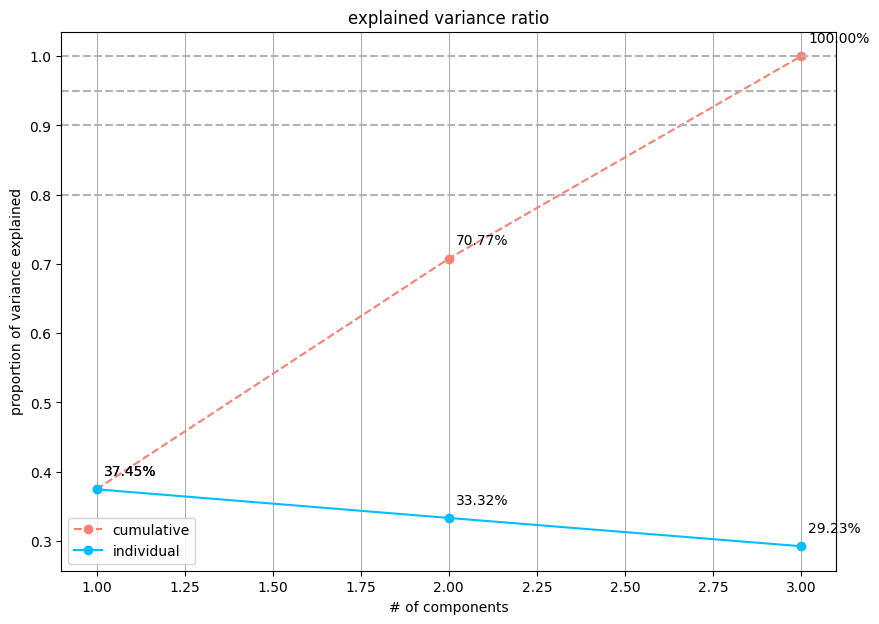

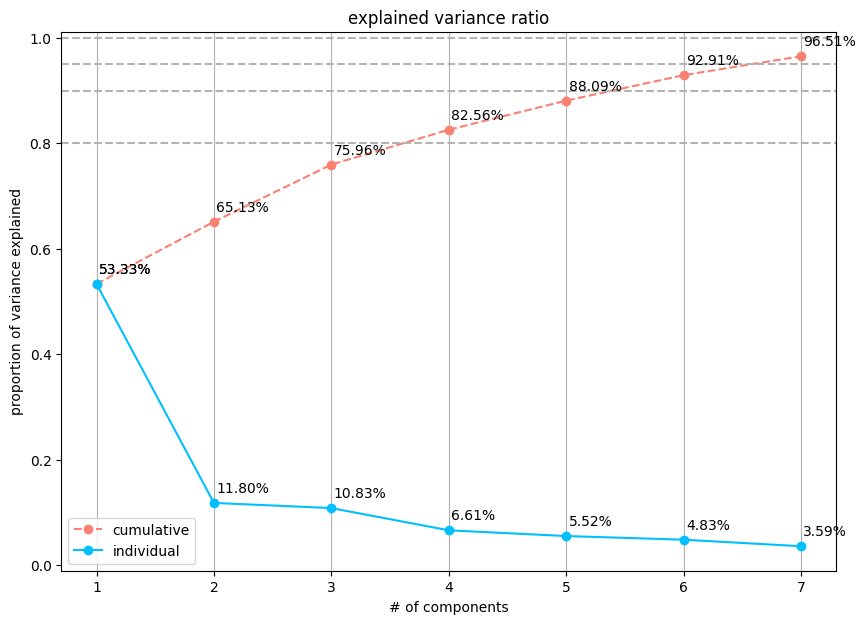

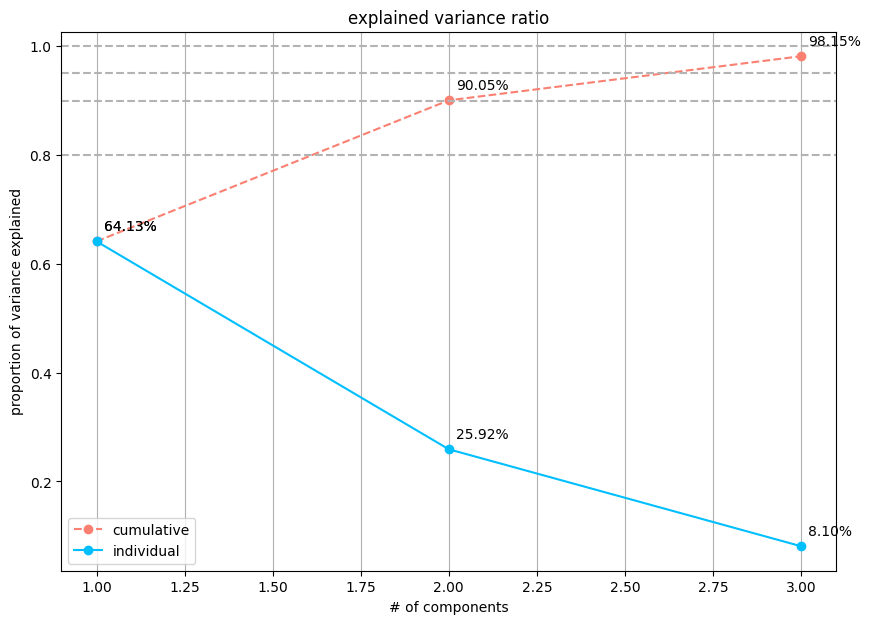

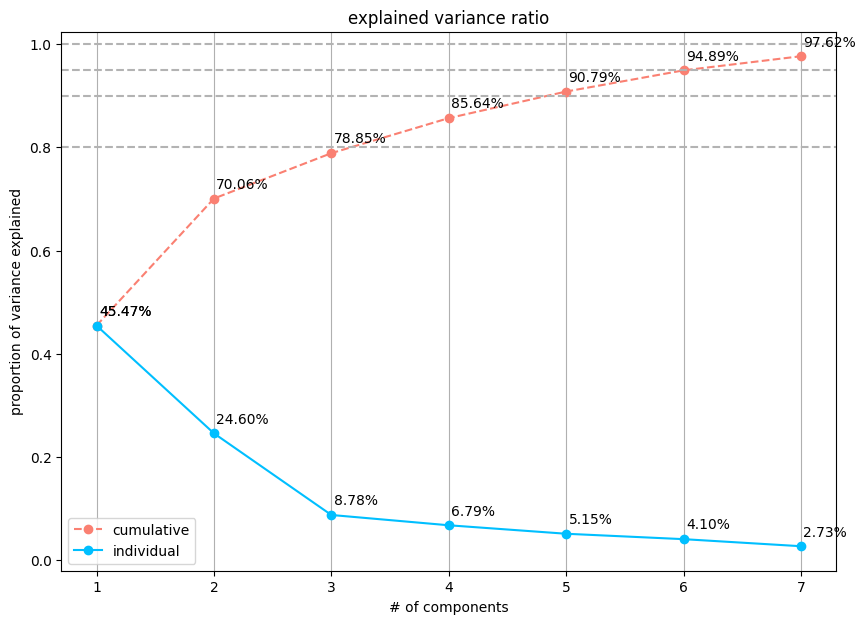

In [489]:
# 2. ตั้งชื่อชุดข้อมูลเพื่อให้ดูผลลัพธ์ง่ายขึ้น (เรียงตามลำดับข้อมูล)
DATASET_NAMES = ["Other Data", "SSTA", "Temperature", "TSA"]

# 3. วนลูปแล้วโยนเข้าฟังก์ชันของคุณ
for name, X_PCA, N_COM in zip(DATASET_NAMES, INPUT_X_PCA, N_COMPONENTS):
    print(f"📊 กำลังประมวลผลและสร้างกราฟสำหรับชุดข้อมูล: {name}")
    
    # เรียกใช้ฟังก์ชันที่คุณเขียนไว้
    ALL_SCEEPLOT_AND_OTHERKEYWORD(X_PCA, N_COM)
    
    print("\n") # เว้นบรรทัดยาวๆ คั่นก่อนเริ่มชุดข้อมูลต่อไป

In [490]:
pca_Other = PCA(n_components= optimal_n_components_other)
pca_SSTA = PCA(n_components= optimal_n_components_SSTA)
pca_temp = PCA(n_components= optimal_n_components_temp)
pca_TSA = PCA(n_components= optimal_n_components_TSA)


pca_Other.fit_transform(X_Otherscalered)
pca_SSTA.fit_transform(X_SSTAscalered)
pca_temp.fit_transform(X_temperaturescalered)
pca_TSA.fit_transform(X_TSAscalered)

array([[-0.05614415,  2.0605664 , -1.10833787, ..., -0.94176444,
         0.31704497,  0.06647962],
       [-0.05614415,  2.0605664 , -1.10833787, ..., -0.94176444,
         0.31704497,  0.06647962],
       [-1.00069436,  1.77990293, -1.01618056, ..., -0.1927578 ,
         0.762552  ,  0.14388671],
       ...,
       [ 0.496955  ,  2.4816845 ,  1.14836635, ...,  3.27694251,
        -1.39261239, -0.03548914],
       [-0.98477295,  1.46097422, -0.21869847, ...,  0.10047182,
         0.78039035,  0.18616901],
       [-0.98477295,  1.46097422, -0.21869847, ...,  0.10047182,
         0.78039035,  0.18616901]])

In [491]:
dd_Other = pd.DataFrame(
    np.dot(X_Otherscalered,pca_Other.components_.T),
    columns=[f'PC_Other{n}' for n in range(1, pca_Other.n_components_ + 1)]
)
dd_Other.head()

,PC_Other1,PC_Other2,PC_Other3
0,-0.115980,-0.730594,0.268454
1,-0.084668,-0.445009,0.293588
2,-0.071636,-0.159032,0.337041
3,-0.104824,-0.444577,0.313787
4,-0.454570,-1.236421,-0.180481


In [492]:
dd_SSTA = pd.DataFrame(
    np.dot(X_SSTAscalered,pca_SSTA.components_.T),
    columns=[f'PC_SSTA{n}' for n in range(1, pca_SSTA.n_components_ + 1)]
)
dd_SSTA.head()

,PC_SSTA1,PC_SSTA2,PC_SSTA3,PC_SSTA4,PC_SSTA5,PC_SSTA6,PC_SSTA7
0,0.298627,-0.995766,-0.598113,0.762166,-0.027924,0.204436,-0.411213
1,0.298627,-0.995766,-0.598113,0.762166,-0.027924,0.204436,-0.411213
2,-0.438824,-0.335041,-1.040476,0.482801,0.638802,0.663342,-0.417204
3,-0.485837,-0.455297,-0.371020,0.751944,0.754977,0.147913,-0.119313
4,1.440056,-1.493978,-1.131518,1.181153,-0.131582,-0.013769,-1.009545


In [493]:
dd_temp = pd.DataFrame(
    np.dot(X_temperaturescalered,pca_temp.components_.T),
    columns=[f'PC_temp{n}' for n in range(1, pca_temp.n_components_ + 1)]
)
dd_temp.head()

,PC_temp1,PC_temp2,PC_temp3
0,2.373429,0.496726,-1.012526
1,2.373429,0.496726,-1.012526
2,2.150001,0.212607,-0.857113
3,2.148187,0.415116,-0.863469
4,3.186508,-0.140007,1.322067


In [494]:
dd_TSA = pd.DataFrame(
    np.dot(X_TSAscalered,pca_TSA.components_.T),
    columns=[f'PC_TSA{n}' for n in range(1, pca_TSA.n_components_ + 1)]
)
dd_TSA.head()

,PC_TSA1,PC_TSA2,PC_TSA3,PC_TSA4,PC_TSA5,PC_TSA6,PC_TSA7
0,-0.056144,2.060566,-1.108338,-0.967077,-0.941764,0.317045,0.066480
1,-0.056144,2.060566,-1.108338,-0.967077,-0.941764,0.317045,0.066480
2,-1.000694,1.779903,-1.016181,-0.526316,-0.192758,0.762552,0.143887
3,-0.971176,1.879708,-1.338848,-0.816011,-0.153296,0.346936,-0.030385
4,-0.527733,3.022969,0.138642,2.187186,-0.748058,-0.778868,-0.441851


In [495]:
dd_allpca = pd.concat([dd_Other, dd_SSTA, dd_temp, dd_TSA], axis=1)
dd_allpca.columns = [f'PC{n}' for n in range(1, dd_allpca.shape[1] + 1)]
dd_allpca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,-0.115980,-0.730594,0.268454,0.298627,-0.995766,-0.598113,0.762166,-0.027924,0.204436,-0.411213,2.373429,0.496726,-1.012526,-0.056144,2.060566,-1.108338,-0.967077,-0.941764,0.317045,0.066480
1,-0.084668,-0.445009,0.293588,0.298627,-0.995766,-0.598113,0.762166,-0.027924,0.204436,-0.411213,2.373429,0.496726,-1.012526,-0.056144,2.060566,-1.108338,-0.967077,-0.941764,0.317045,0.066480
2,-0.071636,-0.159032,0.337041,-0.438824,-0.335041,-1.040476,0.482801,0.638802,0.663342,-0.417204,2.150001,0.212607,-0.857113,-1.000694,1.779903,-1.016181,-0.526316,-0.192758,0.762552,0.143887
3,-0.104824,-0.444577,0.313787,-0.485837,-0.455297,-0.371020,0.751944,0.754977,0.147913,-0.119313,2.148187,0.415116,-0.863469,-0.971176,1.879708,-1.338848,-0.816011,-0.153296,0.346936,-0.030385
4,-0.454570,-1.236421,-0.180481,1.440056,-1.493978,-1.131518,1.181153,-0.131582,-0.013769,-1.009545,3.186508,-0.140007,1.322067,-0.527733,3.022969,0.138642,2.187186,-0.748058,-0.778868,-0.441851


In [496]:
print(f"columns original hvae : {len(df_Clean_already.columns)} ----> using pca of groupby have {len(dd_allpca.columns)}")

columns original hvae : 34 ----> using pca of groupby have 20


## Training model
- RandomForestRegresor
- XGBRegressor

In [497]:
def PLOTING_RESULT_ML(model, X_test, y_test , cl):
    y_test = y_test.ravel()
    y_pred = model.predict(X_test)
    y_pred = y_pred.ravel()

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x=y_test,
        y=y_pred,
        alpha=0.5,
        color=cl
    )

    # เส้น ideal line
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red',
        linestyle='--',
        lw=2
    )

    plt.title('Actual vs Predicted Percent Bleaching (ANN) pca + ANN')
    plt.xlabel('Actual Bleaching (%)')
    plt.ylabel('Predicted Bleaching (%)')

    plt.grid(True, linestyle=':', alpha=0.6)

    plt.show()

#--------------------------------------------------------------------------------------------------------------------------------------------#

def Metric_result(model , X_train , X_test , y_train , y_test):
    print(f"Score on training data: {(model.score(X_train, y_train)).round(3)}") # score from training
    pred = model.predict(X_test)
    print("-" * 30)

    test_mse = mean_squared_error(y_test, pred) # Mean_Squaed_error
    print("Test MSE:", test_mse.round(3))
    print("-" * 30)


    test_rmse = np.sqrt(mean_squared_error(y_test, pred)) # Root_mean_squared_error
    print(f"Test RMSE : {test_rmse.round(3)}")
    print("-" * 30)

    test_r2 = r2_score(y_test, pred) # R2_squared
    print(f"Test R2 Score : {test_r2.round(3)}")
    print("-" * 30)

    test_mae = mean_absolute_error(y_test, pred) # Mean_Absolute_error
    print(f"Mean Absolute Error : {test_mae.round(3)}")
    print("-" * 30)

    test_mape = mean_absolute_percentage_error(y_test, pred) # Mean_Absolute_Percentage_Error
    print(f"Mean Absolute Percentage Error : {test_mape.round(3)}")
    print("-" * 30)
    
    print(pred.shape)
    print(y_test.shape)
    
#--------------------------------------------------------------------------------------------------------------------------------------------#

def RESULT_K_FOLD(results, cv):
    r2 = results['test_r2']
    rmse = np.sqrt(-results['test_neg_mean_squared_error'])
    mae = -results['test_neg_mean_absolute_error']

    # สร้างฟังก์ชันย่อยสำหรับจัดรูปแบบ array ให้อ่านง่ายขึ้น
    format_folds = lambda arr: ", ".join([f"{x:.2f}" for x in arr])

    print("=" * 60)
    print(f"{'K-Fold Cross Validation Results (CV = ' + str(cv) + ')':^60}")
    print("=" * 60)
    print(f"{'Metric':<10} | {'Mean (Std)':<15} | {'Scores per Fold'}")
    print("-" * 60)
    
    # เพิ่มการดูค่า Standard Deviation (std) ด้วยเพื่อดูความเสถียรของโมเดล
    print(f"{'R2':<10} | {r2.mean():.2f} (±{r2.std():.2f})   | {format_folds(r2)}")
    print(f"{'RMSE':<10} | {rmse.mean():.2f} (±{rmse.std():.2f})   | {format_folds(rmse)}")
    print(f"{'MAE':<10} | {mae.mean():.2f} (±{mae.std():.2f})   | {format_folds(mae)}")
    print("=" * 60)
    
#--------------------------------------------------------------------------------------------------------------------------------------------#
    
def feature_importance(model, feature_train):
    importances = model.feature_importances_
    feature_names = feature_train.columns
   
    df_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    print(f"Columns have all : {len(df_importance)}")
    
    return df_importance.round(2)

In [498]:
feature_MLpca = dd_allpca
target_MLpca = df_Clean_already['Percent_Bleaching']

feature_MLpca_values = feature_MLpca.values
target_MLpca_values = target_MLpca.values

In [499]:
seed = 42
X_trainpca , X_testpca , y_trainpca , y_testpca = train_test_split(feature_MLpca_values, target_MLpca_values, test_size=0.2 , random_state=seed)
X_trainpca.shape , y_trainpca.shape , X_testpca.shape , y_testpca.shape

((4889, 20), (4889,), (1223, 20), (1223,))

In [500]:
rfr_pca = RandomForestRegressor(
    n_estimators=200,        # จำนวนต้นไม้
    max_depth=8,             # ห้ามลึกเกิน 8 ชั้น (สำคัญมากในการลด Overfit)
    min_samples_split=10,    # ต้องมีข้อมูลอย่างน้อย 10 แถวถึงจะแตกกิ่งต่อ
    min_samples_leaf=5,      # ปลายกิ่งสุดท้ายต้องมีข้อมูลอย่างน้อย 5 แถว
    random_state=seed,
    n_jobs=-1                # ใช้ CPU เต็มกำลังให้รันเร็วขึ้น
)

rfr_pca.fit(X_trainpca,y_trainpca)

RandomForestRegressor(max_depth=8, min_samples_leaf=5, min_samples_split=10,
                      n_estimators=200, n_jobs=-1, random_state=42)

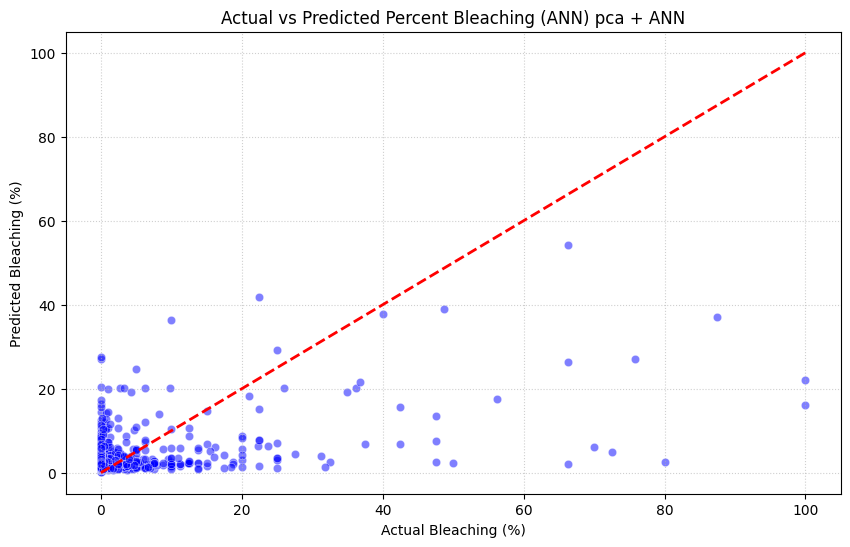

In [501]:
PLOTING_RESULT_ML(rfr_pca, X_testpca, y_testpca , 'blue')

In [502]:
Metric_result(rfr_pca,X_trainpca,X_testpca,y_trainpca,y_testpca)

Score on training data: 0.553
------------------------------
Test MSE: 63.679
------------------------------
Test RMSE : 7.98
------------------------------
Test R2 Score : 0.261
------------------------------
Mean Absolute Error : 3.539
------------------------------
Mean Absolute Percentage Error : 5980894120495594.0
------------------------------
(1223,)
(1223,)


##

==================
### XGBRegessor
==================

In [503]:
# 1. สร้างโมเดล XGBoost พร้อมตั้งค่าพารามิเตอร์เบื้องต้นเพื่อกัน Overfit
xgb_modelpca = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,            # ไม่ต้องลึกมาก XGBoost ฉลาดพอ
    learning_rate=0.05,     # ค่อยๆ เรียนรู้ทีละนิด (ยิ่งน้อยยิ่งแม่น แต่เทรนนาน)
    subsample=0.8,          # สุ่มข้อมูลมาเทรน 80% ต่อรอบ (ช่วยกันจำข้อสอบ)
    colsample_bytree=0.8,   # สุ่มตัวแปรมา 80% ต่อรอบ
    random_state=seed,
    n_jobs=-1
)

# 2. เทรนโมเดล
xgb_modelpca.fit(X_trainpca, y_trainpca)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

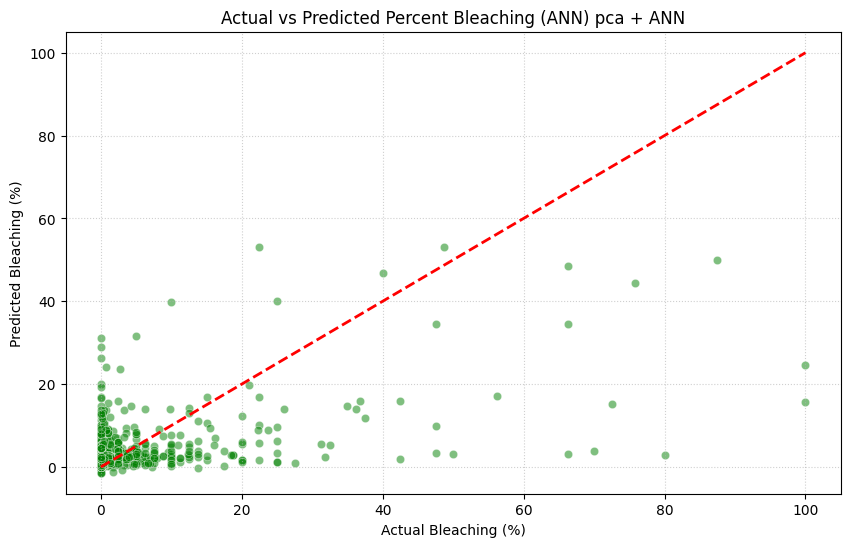

In [504]:
PLOTING_RESULT_ML(xgb_modelpca, X_testpca, y_testpca , 'green')

In [505]:
Metric_result(xgb_modelpca,X_trainpca,X_testpca,y_trainpca,y_testpca)

Score on training data: 0.801
------------------------------
Test MSE: 61.06
------------------------------
Test RMSE : 7.814
------------------------------
Test R2 Score : 0.291
------------------------------
Mean Absolute Error : 3.375
------------------------------
Mean Absolute Percentage Error : 5469908284733989.0
------------------------------
(1223,)
(1223,)


In [506]:
#------------------------------------------------------------------------#
# โมเดล Average bleaching
#------------------------------------------------------------------------#


y_pred_Averagemodel = df_Clean_already[['Percent_Bleaching']].mean()

def RMSE(df):
    y_true = df['Percent_Bleaching'].values
    total = 0
    
    for i in range(len(y_true)):
        error = y_true[i] - y_pred_Averagemodel
        total += error**2
    
    rmse = np.sqrt(total / len(y_true))
    return rmse

print(f"RMSE : {RMSE(df_Clean_already).round(2)}")

def R2_score(df):
    y_true = df['Percent_Bleaching'].values
    
    y_mean = np.mean(y_true)
    
    ss_res = 0  # sum of squared residuals
    ss_tot = 0  # total sum of squares
    
    for i in range(len(y_true)):
        ss_res += (y_true[i] - y_pred_Averagemodel)**2
        ss_tot += (y_true[i] - y_mean)**2
    
    r2 = 1 - (ss_res / ss_tot)
    
    print(f"SS_res : {ss_res.round(1)}")
    print(f"SS_tot : {ss_tot.round(1)}")
    
    return r2

print(f"Percent_bleaching : {y_pred_Averagemodel}")
print("-"*50)
print(f"R2_score (rounded): {R2_score(df_Clean_already)}") # predicted less than mean so R2 is negative

RMSE : Percent_Bleaching    9.63
dtype: float64
Percent_bleaching : Percent_Bleaching    2.79522
dtype: float64
--------------------------------------------------
SS_res : Percent_Bleaching    567199.4
dtype: float64
SS_tot : 567199.4
R2_score (rounded): Percent_Bleaching    0.0
dtype: float64


##

=======================================
### Artificial Neural Network
=======================================

In [507]:
# tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense , Dropout, Input
from keras.metrics import RootMeanSquaredError, MeanAbsoluteError, MeanSquaredError
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

# scikit-learn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler , RobustScaler
from sklearn.model_selection import KFold


In [508]:
def Divide_data(df_feature, df_target, n_train):
    
    n = len(df_feature)
    n_train = n * n_train
    n_train = int(n_train)
    
    return df_feature[:n_train], df_feature[n_train:], df_target[:n_train], df_target[n_train:]

X_trainANN_pca, X_testANN_pca, y_trainANN_pca, y_testANN_pca = Divide_data(feature_MLpca_values, target_MLpca_values, 0.8)
X_trainANN_pca.shape, X_testANN_pca.shape , y_trainANN_pca.shape, y_testANN_pca.shape
    

((4889, 20), (1223, 20), (4889,), (1223,))

In [509]:
scaler_X = RobustScaler()
scaler_y = RobustScaler()

# ✅ fit เฉพาะ train
X_trainANNpca_scaled = scaler_X.fit_transform(X_trainANN_pca)
X_testANNpca_scaled  = scaler_X.transform(X_testANN_pca)

# เพิ่ม .to_numpy() ก่อน .reshape(-1, 1)
y_trainANNpca_scaled = scaler_y.fit_transform(y_trainANN_pca.reshape(-1, 1)).flatten()
y_testANNpca_scaled  = scaler_y.transform(y_testANN_pca.reshape(-1, 1)).flatten()

In [510]:
def model_ANN(X_train):
        model = Sequential(
        [
            Dense(64, activation= 'relu', input_shape=(X_train.shape[1],)),
            Dropout(0.1),
            Dense(32, activation= 'relu'),
            Dense(1)
        ]
    )
        return model

model_temp = model_ANN(X_trainANN_pca)

#------------------------------------------------------------------#
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

In [511]:
def K_Fold_cross_validation(model, X_train, y_train):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    Epoch = [8, 16, 32, 64, 128]
    Batch_size = [8, 16, 32, 64]
    fold = 1
    Error = []
    early_stopping = EarlyStopping(monitor='val_loss', patience=10)

    for train_idx, val_idx in kf.split(X_train):
        
        print(f"\n==================== Fold {fold} ====================")

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        # ✅ 1. Reshape y ให้เป็น 2 มิติเพื่อเข้า Scaler
        y_tr_reshaped = y_tr.reshape(-1, 1)
        y_val_reshaped = y_val.reshape(-1, 1)

        # ✅ 2. ใช้ MinMaxScaler (แนะนำให้ใช้ตัวนี้คู่กับ Log Transform จะดีกับ ANN ที่สุดครับ)
        scaler_X = RobustScaler()
        scaler_y = RobustScaler()
        
        # ✅ 3. Fit และ Transform **เฉพาะข้อมูล Train (X_tr, y_tr)** ของ Fold นี้
        X_tr_scaled = scaler_X.fit_transform(X_tr)
        y_tr_scaled = scaler_y.fit_transform(y_tr_reshaped)
        
        # ✅ 4. Transform ข้อมูล Validation โดยใช้ความรู้จาก Train
        X_val_scaled = scaler_X.transform(X_val)
        y_val_scaled = scaler_y.transform(y_val_reshaped)

        model.compile(
            optimizer=Adam(learning_rate=0.01),
            loss='mse',
            metrics=[RootMeanSquaredError(), MeanAbsoluteError()]
        )

        # ✅ 5. โยนข้อมูลที่ **Scale แล้ว** เข้าไปเทรนโมเดล
        history = model.fit(
            X_tr_scaled, y_tr_scaled,
            validation_data=(X_val_scaled, y_val_scaled),
            epochs=Epoch[3],
            batch_size=Batch_size[1],
            callbacks=[early_stopping], # ตรวจสอบให้แน่ใจว่าประกาศตัวแปรนี้ไว้ข้างนอกแล้ว
            verbose=1
        )

        # ✅ 6. คืนร่าง Target (Inverse Transform) ก่อนหาค่า Error จริง
        # ให้โมเดลทำนายจาก X_val_scaled
        y_pred_scaled = model.predict(X_val_scaled)
        
        # แปลงกลับเป็นสเกล 0-100% 
        y_pred_real = scaler_y.inverse_transform(y_pred_scaled).flatten()
        y_val_real = y_val.flatten() # ใช้ค่า y_val ดั้งเดิมที่ยังไม่ถูก Scale มาเทียบได้เลย
        
        # คำนวณ Metrics จากสเกลจริง (ทำให้ MAE และ RMSE อ่านค่าได้เข้าใจง่าย)
        rmse_real = np.sqrt(mean_squared_error(y_val_real, y_pred_real))
        mae_real = mean_absolute_error(y_val_real, y_pred_real)
        r2_real = r2_score(y_val_real, y_pred_real)

        # ดึงค่า Loss (MSE) จากสเกลเลอร์ของ Keras เพื่อเก็บ History
        loss = model.evaluate(X_val_scaled, y_val_scaled, verbose=0)[0] 

        Error.append({
            "Storage RMSE Fold": fold,
            "loss": loss,
            "MAE": mae_real,          # ✅ เก็บค่าจริง
            "RMSE Values": rmse_real, # ✅ เก็บค่าจริง
            'R2' : r2_real,           # ✅ เก็บค่าจริง
            "history_of_loss": history.history['loss'],
            "history_of_val_loss": history.history['val_loss']
        })

        fold += 1

    return Error

#------------------------------------------------------------------------------------------#
Error_En = K_Fold_cross_validation(model_temp,X_trainANNpca_scaled,y_trainANNpca_scaled)
#------------------------------------------------------------------------------------------#


==================== Fold 1 ====================
Epoch 1/64
245/245 [==============================] - 1s 2ms/step - loss: 81.7518 - root_mean_squared_error: 9.0417 - mean_absolute_error: 3.7524 - val_loss: 65.5501 - val_root_mean_squared_error: 8.0963 - val_mean_absolute_error: 3.2563
Epoch 2/64
245/245 [==============================] - 0s 1ms/step - loss: 76.3921 - root_mean_squared_error: 8.7403 - mean_absolute_error: 3.5640 - val_loss: 65.6668 - val_root_mean_squared_error: 8.1035 - val_mean_absolute_error: 3.1094
Epoch 3/64
245/245 [==============================] - 0s 1ms/step - loss: 71.5388 - root_mean_squared_error: 8.4581 - mean_absolute_error: 3.5072 - val_loss: 57.3588 - val_root_mean_squared_error: 7.5736 - val_mean_absolute_error: 3.2838
Epoch 4/64
245/245 [==============================] - 0s 1ms/step - loss: 71.9608 - root_mean_squared_error: 8.4830 - mean_absolute_error: 3.5652 - val_loss: 66.7896 - val_root_mean_squared_error: 8.1725 - val_mean_absolute_error: 4.369

         K-Fold Cross Validation Results
 Fold      Loss     RMSE      MAE       R2
    1 55.681503 7.462004 3.128035 0.222037
    2 41.667915 6.455069 2.787355 0.548407
    3 64.151344 8.009453 3.418923 0.437308
    4 28.466671 5.335417 2.717538 0.525045
    5 31.039310 5.571294 2.621565 0.655083
  Mean  Loss : 44.2013
  Std   Loss : 15.4680
------------------------------
  Mean  RMSE : 6.5666
  Std   RMSE : 1.1622
------------------------------
  Mean  MAE  : 2.9347
  Std   MAE  : 0.3312
------------------------------
  Mean  R2   : 0.4776
  Std   R2   : 0.1626


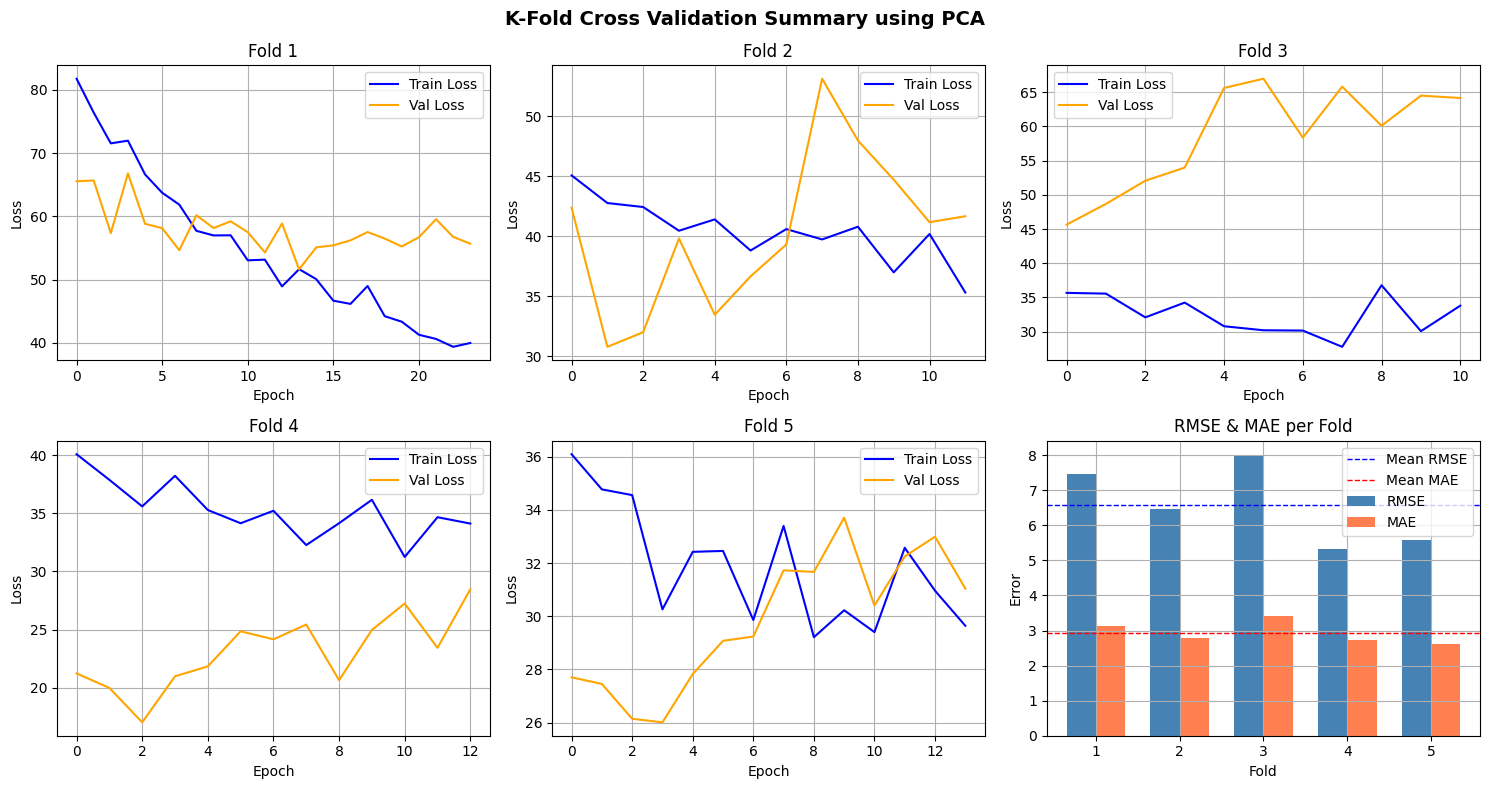

In [513]:
def show_kfold_results(Error):
    
    # ── 1. สรุปตาราง ──────────────────────────────────────────
    df_results = pd.DataFrame([{
        "Fold"  : e["Storage RMSE Fold"],
        "Loss"  : e["loss"],
        "RMSE"  : e["RMSE Values"],
        "MAE"   : e["MAE"],
        "R2"    : e["R2"]
    } for e in Error])
    
    print("=" * 50)
    print("         K-Fold Cross Validation Results")
    print("=" * 50)
    print(df_results.to_string(index=False))
    print("=" * 50)
    print(f"  Mean  Loss : {df_results['Loss'].mean():.4f}")
    print(f"  Std   Loss : {df_results['Loss'].std():.4f}")
    print("-" * 30)
    print(f"  Mean  RMSE : {df_results['RMSE'].mean():.4f}")
    print(f"  Std   RMSE : {df_results['RMSE'].std():.4f}")
    print("-" * 30)
    print(f"  Mean  MAE  : {df_results['MAE'].mean():.4f}")
    print(f"  Std   MAE  : {df_results['MAE'].std():.4f}")
    print("-" * 30)
    print(f"  Mean  R2   : {df_results['R2'].mean():.4f}")
    print(f"  Std   R2   : {df_results['R2'].std():.4f}")
    print("=" * 50)
    
    # ── 2. Plot Loss curve แต่ละ Fold ─────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for i, e in enumerate(Error):
        ax = axes[i]
        ax.plot(e["history_of_loss"],     label="Train Loss", color="blue")
        ax.plot(e["history_of_val_loss"], label="Val Loss",   color="orange")
        ax.set_title(f"Fold {e['Storage RMSE Fold']}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(True)
    
    # ── slot สุดท้าย → สรุป RMSE/MAE ทุก fold ────────────────
    ax = axes[len(Error)]
    x = df_results["Fold"]
    width = 0.35
    ax.bar(x - width/2, df_results["RMSE"], width, label="RMSE", color="steelblue")
    ax.bar(x + width/2, df_results["MAE"],  width, label="MAE",  color="coral")
    ax.axhline(df_results["RMSE"].mean(), color="blue",   linestyle="--", linewidth=1, label="Mean RMSE")
    ax.axhline(df_results["MAE"].mean(),  color="red",    linestyle="--", linewidth=1, label="Mean MAE")
    ax.set_title("RMSE & MAE per Fold")
    ax.set_xlabel("Fold")
    ax.set_ylabel("Error")
    ax.set_xticks(x)
    ax.legend()
    ax.grid(True)
    
    plt.suptitle("K-Fold Cross Validation Summary using PCA", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    return df_results

def PLOTING_DEEP_LEARNING(model, X_test, y_test, scale, CL):
    # 1. Predict ค่าออกมา (ค่าที่ได้จะยังเป็นสเกลที่ถูกแปลงอยู่)
    y_pred_scaled = model.predict(X_test)

    # 2. แปลงค่ากลับเป็นสเกลปกติ (เปอร์เซ็นต์) ด้วย inverse_transform
    # หมายเหตุ: .reshape(-1, 1) เผื่อไว้ในกรณีที่ y_pred ออกมาเป็น 1D
    y_pred_original = scale.inverse_transform(y_pred_scaled.reshape(-1, 1))

    # 3. แปลงกลับเป็น 1D สำหรับการพล็อตกราฟ
    y_pred_plot = y_pred_original.ravel()
    
    # *ข้อควรระวัง*: y_test ที่รับเข้ามา ต้องเป็นสเกลปกติ (%) ด้วยนะครับ 
    # (ถ้า y_test เป็นค่าที่โดนสเกลมา ต้อง inverse_transform y_test ด้วยเช่นกัน)

    plt.figure(figsize=(10, 6))

    # พล็อต Scatter
    sns.scatterplot(
        x=y_test, 
        y=y_pred_plot,
        alpha=0.5,
        color=CL
    )

    # 4. หาขอบเขตที่กว้างที่สุดสำหรับวาดเส้น Ideal Line (ใช้ค่าจากพารามิเตอร์ ไม่ใช่ตัวแปร Global)
    min_val = min(np.min(y_test), np.min(y_pred_plot))
    max_val = max(np.max(y_test), np.max(y_pred_plot))

    # เส้น ideal line (Perfect prediction)
    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        color='red',
        linestyle='--',
        lw=2
    )

    plt.title('Actual vs Predicted Percent Bleaching (ANN) pca + ANN')
    plt.xlabel('Actual Bleaching (%)')
    plt.ylabel('Predicted Bleaching (%)')

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# เรียกใช้
df_results = show_kfold_results(Error_En)

39/39 [==============================] - 0s 1ms/step


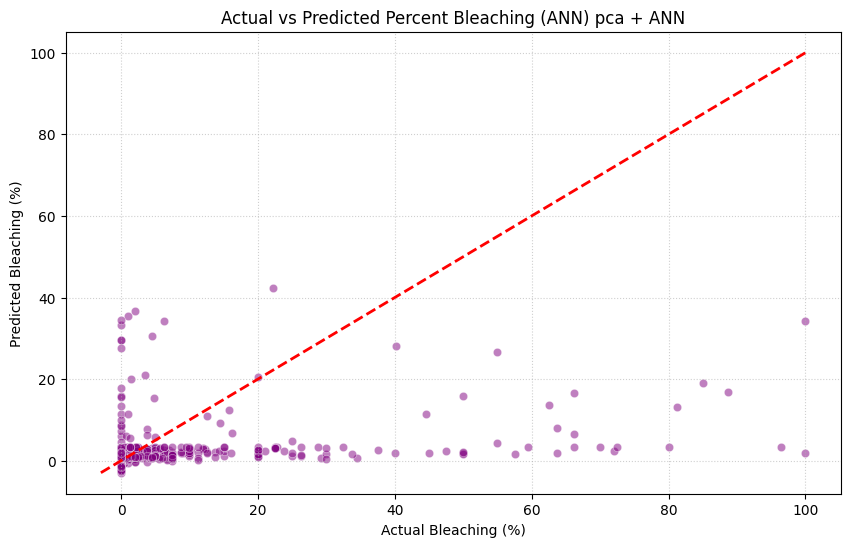

In [514]:
PLOTING_DEEP_LEARNING(model_temp, X_testANNpca_scaled, y_testANN_pca , scaler_y , 'purple')